In [1]:
import utils_phenom as up
import utils_signal as using
import importlib

importlib.reload(up)
importlib.reload(using)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI
out_dir = "./spectrograms_figures/"


/home/pycbc/work/Memory_Lopez/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


/usr/local/lib/python3.11/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


lal.MSUN_SI != Msun
Chirp max strain : 2.23e-20
Memory max strain: 3.83e-23
fs_mem=200.0 Hz, nperseg_mem=200, df_mem=1.00 Hz


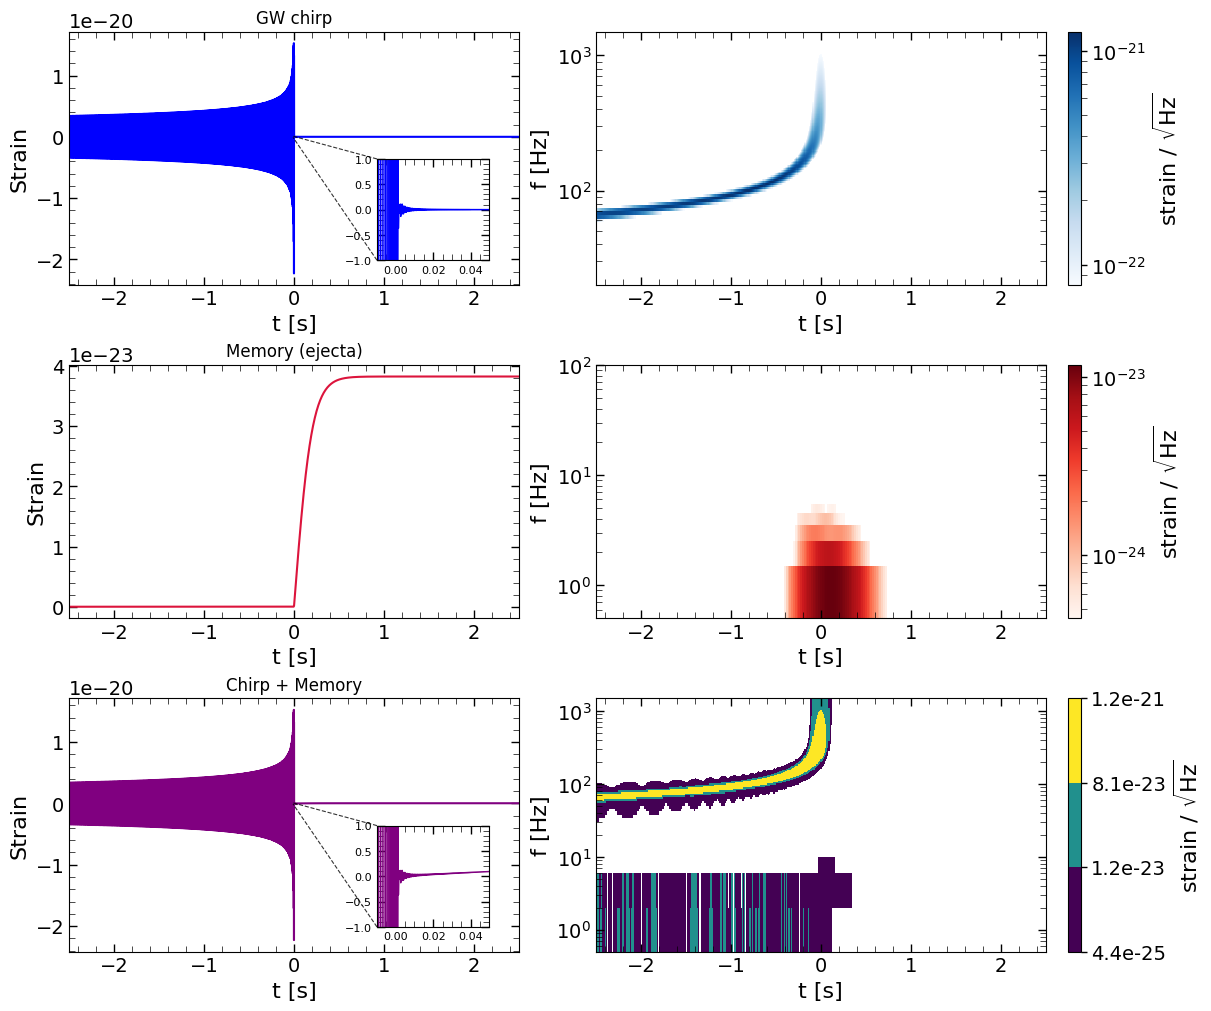

In [2]:
from scipy.signal import spectrogram as scipy_spectrogram
from matplotlib.colors import LogNorm, BoundaryNorm
import numpy as np
import matplotlib.pyplot as plt
import utils_signal as usig
import utils_phenom as up
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Chirp signal 
mtot = 5
m1 = m2 = mtot / 2
dt_chirp = 1/4096
fs_chirp = 4096
distance = 1
time_raw, raw_signal, hc = usig.get_hp_hc_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    distance=distance,
    delta_t=dt_chirp,
    f_lower=20.,
    inclination=np.pi/2
)

mask = (time_raw >= -10) & (time_raw <= 2)
time_raw = time_raw[mask]
raw_signal = raw_signal[mask]

aligned_time, aligned_signal = usig.align_signal(raw_signal, time_raw)
padded_time, padded_signal = usig.pad_signal(aligned_signal, aligned_time, r=0.5)

# Memory signal with adapted dt 
tau = 0.1          
fs_mem = 20 * 1/tau # Nyquist = 100 Hz >> f_char = 10 Hz
dt_m = 1 / fs_mem
t_start = padded_time[0]
t_end_sig = padded_time[-1]
pad_dur = 5.0       
t_mem = np.arange(t_start - pad_dur, t_end_sig + pad_dur, dt_m)

M_ej = 0.01
v_ej = 0.2
r = 1e6  # 1 Mpc
h_t = up.linear_memory_ejecta_masked(t_mem, M_ej, v_ej, tau, r, 0, model='exponential')
# Pad with last value (plateau) to avoid jump to 0
pad_samples_mem = int(pad_dur * fs_mem)
h_t_padded = np.pad(h_t, pad_samples_mem, mode='edge')
t_mem_padded = np.arange(
    t_mem[0] - pad_dur,
    t_mem[-1] + pad_dur + dt_m,
    dt_m
)[:len(h_t_padded)]

#  Resample memory onto chirp time grid for later sum 
from scipy.interpolate import interp1d
h_t_interp = interp1d(t_mem_padded, h_t_padded, bounds_error=False, fill_value=h_t_padded[-1])
memory_signal_resampled = h_t_interp(padded_time)

#  Sum signal : chirp + memory 
sum_signal = padded_signal + memory_signal_resampled

# Chirp spectrogram 
nperseg_chirp  = 1024   # df = 4096/1024 = 4 Hz
noverlap_chirp = int(0.95 * nperseg_chirp)
f_spec_c, t_spec_c, Sxx_c = scipy_spectrogram(
    padded_signal, fs=fs_chirp,
    nperseg=nperseg_chirp, noverlap=noverlap_chirp,
    window='hann'
)
t_spec_c += padded_time[0]
amp_chirp = np.sqrt(Sxx_c)

#  Memory spectrogram 
nperseg_mem  = int(fs_mem * 1.0)
noverlap_mem = int(0.98 * nperseg_mem)
f_spec_m, t_spec_m, Sxx_m = scipy_spectrogram(
    h_t_padded, fs=fs_mem,
    nperseg=nperseg_mem, noverlap=noverlap_mem,
    window='hann'
)
t_spec_m += t_mem_padded[0]
amp_mem = np.sqrt(Sxx_m)

#  Sum spectrogram 
f_spec_s, t_spec_s, Sxx_s = scipy_spectrogram(
    sum_signal, fs=fs_chirp,
    nperseg=nperseg_chirp, noverlap=noverlap_chirp,
    window='hann'
)
t_spec_s += padded_time[0]
amp_sum = np.sqrt(Sxx_s)

h_max_chirp = np.max(np.abs(padded_signal))
h_max_mem   = np.max(np.abs(h_t))
print(f"Chirp max strain : {h_max_chirp:.2e}")
print(f"Memory max strain: {h_max_mem:.2e}")
print(f"fs_mem={fs_mem} Hz, nperseg_mem={nperseg_mem}, df_mem={fs_mem/nperseg_mem:.2f} Hz")

#  Normalisations 
vmin_c, vmax_c = np.percentile(amp_chirp[amp_chirp > 0], [99., 100])
vmin_m, vmax_m = np.percentile(amp_mem[amp_mem > 0],     [99., 100])

norm_chirp = LogNorm(vmin=vmin_c, vmax=vmax_c)
norm_mem   = LogNorm(vmin=vmin_m, vmax=vmax_m)

# Colorbar disjointe pour le dernier spectrogramme (sum)
# On force une coupure entre les deux intervalles

bounds = [vmin_m, vmax_m, vmin_c, vmax_c]
norm_disjoint = BoundaryNorm(bounds, ncolors=256, extend='neither')

#  Plot : 3 rows (chirp / memory / sum), 2 columns (time / spectrogram) 
signals = [
    (padded_time, padded_signal, amp_chirp, t_spec_c, f_spec_c, "GW chirp","blue","Blues",norm_chirp, vmin_c),
    (padded_time, memory_signal_resampled, amp_mem,   t_spec_m, f_spec_m, "Memory (ejecta)", "crimson", "Reds",norm_mem,vmin_m),
    (padded_time, sum_signal, amp_sum, t_spec_s, f_spec_s, "Chirp + Memory","purple", "viridis", norm_disjoint, vmin_m),
]

fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

for i, (t_sig, sig_t, amp_spec, t_spec, f_spec, title, color, cmap, norm, vmin) in enumerate(signals):
    # Time domain
    axs[i, 0].plot(t_sig, sig_t, color=color, lw=1.5)
    axs[i, 0].set_title(title)
    axs[i, 0].set_xlabel("t [s]")
    axs[i, 0].set_ylabel("Strain")
    axs[i, 0].set_xlim(-2.5, 2.5)
    axs[i, 0].grid(False)

    # Spectrogram
    amp_masked = np.ma.masked_less_equal(amp_spec, vmin * 1.005)
    pcm = axs[i, 1].pcolormesh(
        t_spec, f_spec, amp_masked,
        shading='auto', cmap=cmap, norm=norm
    )
    axs[i, 1].set_yscale('log')
    if i == 1:
        axs[i, 1].set_ylim(0.5, 100)
    else:
        axs[i, 1].set_ylim(20, 1500)
    axs[i, 1].set_xlim(-2.5, 2.5)
    axs[i, 1].set_xlabel("t [s]")
    axs[i, 1].set_ylabel("f [Hz]")
    axs[i, 1].grid(False)

    # Colorbar personnalisée pour la dernière ligne
    if i == 2:
        axs[i,1].set_ylim(0.5, 1500)
        cb = fig.colorbar(
            pcm, ax=axs[i, 1], label=r'strain / $\sqrt{\mathrm{Hz}}$',
            boundaries=bounds, ticks=[vmin_m, vmax_m, vmin_c, vmax_c]
        )
        cb.ax.set_yticklabels([f"{vmin_m:.1e}", f"{vmax_m:.1e}", f"{vmin_c:.1e}", f"{vmax_c:.1e}"])
    else:
        cb = fig.colorbar(pcm, ax=axs[i, 1], label=r'strain / $\sqrt{\mathrm{Hz}}$')
    cb.ax.tick_params(which='both', direction='out', length=4)
  
    if i in [0, 2]:
        ax_ins = inset_axes(
            axs[i, 0],
            width="25%", height="40%",
            loc='lower right',
            bbox_to_anchor=(-0.05, 0.07, 1, 1),
            bbox_transform=axs[i, 0].transAxes
        )
        # Plot the time-domain signal in the inset 
        ax_ins.plot(t_sig, sig_t, color=color, lw=1.0)
        ax_ins.set_xlim(-0.01, 0.05)   # zoom around merger
        mask_zoom = (t_sig >= -0.01) & (t_sig <= 0.05)
        if mask_zoom.any():
            ax_ins.set_ylim(-0.01*1e-20, 0.01*1e-20)
        ax_ins.tick_params(axis='both', which='major', labelsize=8,
                           direction='in', top=True, right=True)
        ax_ins.yaxis.offsetText.set_visible(False)
        ax_ins.grid(False)
        
        mark_inset(axs[i, 0], ax_ins, loc1=2, loc2=3,
                   fc="none", ec="black", lw=0.8, linestyle="--", alpha=0.8)

#plt.savefig(out_dir + "spectrogram_chirp_memory_stft_rows.png", dpi=150)
plt.show()

Chirp max strain: 2.23e-20
Memory max strain: 3.83e-23
fs_mem=200.0 Hz, nperseg_mem=200, df_mem=1.00 Hz


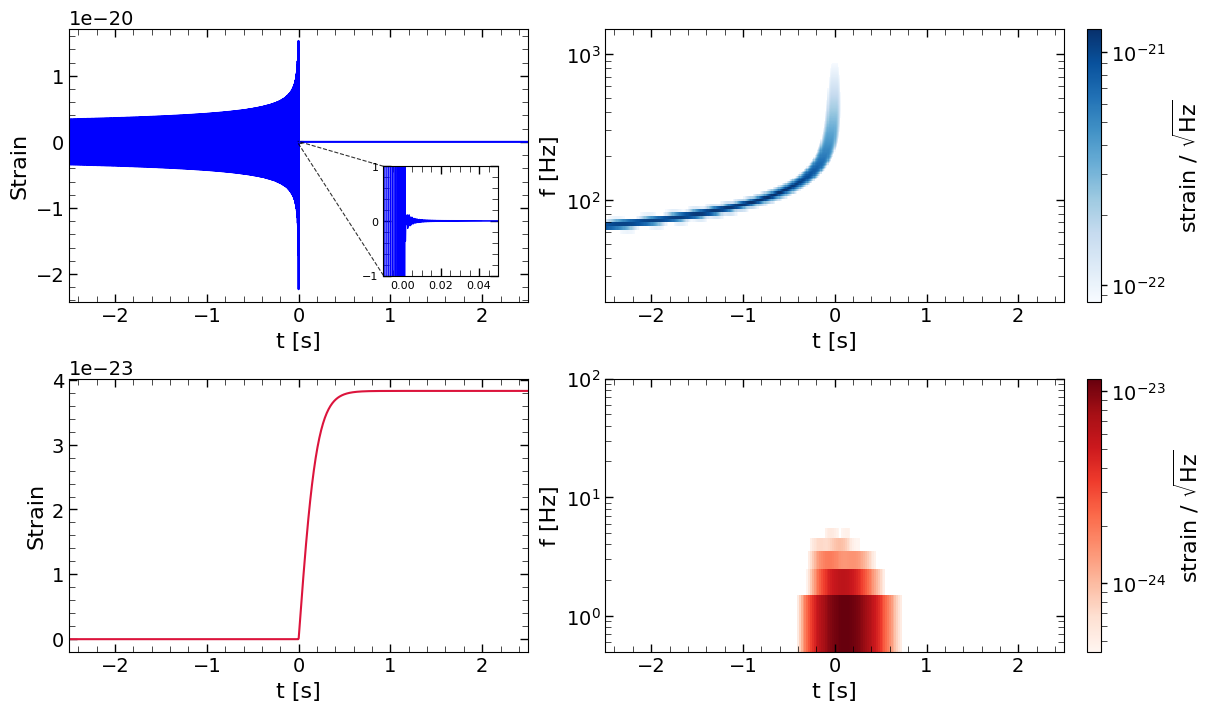

In [ ]:
from scipy.signal import spectrogram as scipy_spectrogram
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
import utils_signal as usig
import utils_phenom as up
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Chirp signal
mtot = 5
m1 = m2 = mtot / 2
dt_chirp = 1 / 4096
fs_chirp = 4096
distance = 1

time_raw, raw_signal, hc = usig.get_hp_hc_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    distance=distance,
    delta_t=dt_chirp,
    f_lower=20.,
    inclination=np.pi / 2
)

mask = (time_raw >= -10) & (time_raw <= 2)
time_raw = time_raw[mask]
raw_signal = raw_signal[mask]

aligned_time, aligned_signal = usig.align_signal(raw_signal, time_raw)

# Padding/taper chirp: padding duration tied to signal duration
chirp_duration = aligned_time[-1] - aligned_time[0]

t_chirp, h_chirp = usig.pad_and_taper(
    aligned_signal, aligned_time,
    padding_length=10,
    window_type='tukey',
    alpha=0.0
)

# Memory signal with adapted dt
tau = 0.1
fs_mem = 20 * (1 / tau)  # Nyquist = 100 Hz >> f_char ~ 10 Hz
dt_m = 1 / fs_mem
pad_len_mem = 0.2

# Build memory on chirp support, then taper with extra right padding
t_mem = np.arange(t_chirp[0], t_chirp[-1], dt_m)
M_ej = 0.01
v_ej = 0.2
r = 1e6  # 1 Mpc

h_mem = up.linear_memory_ejecta_masked(
    t_mem, M_ej, v_ej, tau, r, 0, model='exponential'
)

t_mem_tapered, h_mem_tapered = usig.pad_and_taper(
    h_mem, t_mem,
    padding_length=pad_len_mem,
    window_type='tukey',
    alpha=0.
)

# Chirp spectrogram
nperseg_chirp = 1024      # df = 4096/1024 = 4 Hz
noverlap_chirp = int(0.95 * nperseg_chirp)
f_spec_c, t_spec_c, Sxx_c = scipy_spectrogram(
    h_chirp, fs=fs_chirp,
    nperseg=nperseg_chirp, noverlap=noverlap_chirp, 
    window=('tukey', 0.8)
)
t_spec_c += t_chirp[0]
amp_chirp = np.sqrt(Sxx_c)

# Memory spectrogram
nperseg_mem = int(fs_mem * 1.0)
noverlap_mem = int(0.98 * nperseg_mem)
f_spec_m, t_spec_m, Sxx_m = scipy_spectrogram(
    h_mem_tapered, fs=fs_mem,
    nperseg=nperseg_mem, noverlap=noverlap_mem,
    window=('tukey', 1)
)
t_spec_m += t_mem_tapered[0]
amp_mem = np.sqrt(Sxx_m)

h_max_chirp = np.max(np.abs(h_chirp))
h_max_mem = np.max(np.abs(h_mem_tapered))
print(f"Chirp max strain: {h_max_chirp:.2e}")
print(f"Memory max strain: {h_max_mem:.2e}")
print(f"fs_mem={fs_mem} Hz, nperseg_mem={nperseg_mem}, df_mem={fs_mem/nperseg_mem:.2f} Hz")

# Normalizations
vmin_c, vmax_c = np.percentile(amp_chirp[amp_chirp > 0], [99., 100])
vmin_m, vmax_m = np.percentile(amp_mem[amp_mem > 0], [99., 100])

norm_chirp = LogNorm(vmin=vmin_c, vmax=vmax_c)
norm_mem = LogNorm(vmin=vmin_m, vmax=vmax_m)

# Plot: 2 rows only (chirp / memory), 2 columns (time / spectrogram)
signals = [
    (t_chirp, h_chirp, amp_chirp, t_spec_c, f_spec_c, "GW chirp", "blue", "Blues", norm_chirp, vmin_c),
    (t_mem_tapered, h_mem_tapered, amp_mem, t_spec_m, f_spec_m, "Memory (ejecta)", "crimson", "Reds", norm_mem, vmin_m),
]

fig, axs = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

for i, (t_sig, sig_t, amp_spec, t_spec, f_spec, title, color, cmap, norm, vmin) in enumerate(signals):
    # Time domain
    axs[i, 0].plot(t_sig, sig_t, color=color, lw=1.5)
    axs[i, 0].set_xlabel("t [s]")
    axs[i, 0].set_ylabel("Strain")
    axs[i, 0].set_xlim(-2.5, 2.5)
    axs[i, 0].grid(False)

    # Spectrogram
    amp_masked = np.ma.masked_less_equal(amp_spec, vmin * 1.005)
    pcm = axs[i, 1].pcolormesh(
        t_spec, f_spec, amp_masked,
        shading='auto', cmap=cmap, norm=norm
    )
    axs[i, 1].set_yscale('log')
    if i == 1:
        axs[i, 1].set_ylim(0.5, 100)
    else:
        axs[i, 1].set_ylim(20, 1500)
    axs[i, 1].set_xlim(-2.5, 2.5)
    axs[i, 1].set_xlabel("t [s]")
    axs[i, 1].set_ylabel("f [Hz]")
    axs[i, 1].grid(False)

    cb = fig.colorbar(pcm, ax=axs[i, 1], label=r'strain / $\sqrt{\mathrm{Hz}}$')
    cb.ax.tick_params(which='both', direction='out', length=4)

    # Inset only for chirp row
    if i == 0:
        ax_ins = inset_axes(
            axs[i, 0],
            width="25%", height="40%",
            loc='lower right',
            bbox_to_anchor=(-0.05, 0.07, 1, 1),
            bbox_transform=axs[i, 0].transAxes
        )
        ax_ins.plot(t_sig, sig_t, color=color, lw=1.0)
        ax_ins.set_xlim(-0.01, 0.05)
        mask_zoom = (t_sig >= -0.01) & (t_sig <= 0.05)
        if mask_zoom.any():
            ax_ins.set_ylim(-0.01e-20, 0.01e-20)
        ax_ins.tick_params(axis='both', which='major', labelsize=8, direction='in', top=True, right=True)
        ax_ins.yaxis.offsetText.set_visible(False)
        ax_ins.grid(False)

        mark_inset(
            axs[i, 0], ax_ins, loc1=2, loc2=3,
            fc="none", ec="black", lw=0.8, linestyle="--", alpha=0.8
        )

# plt.savefig(out_dir + "spectrogram_chirp_memory_stft_rows.png", dpi=150)
plt.show()

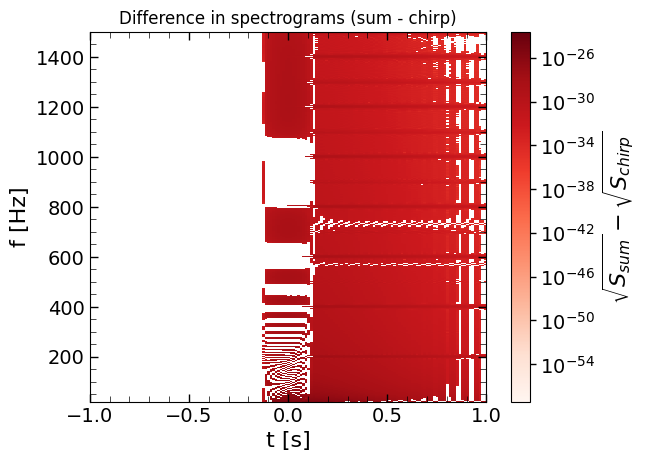

In [17]:
amp_diff = amp_sum - amp_chirp
plt.pcolormesh(t_spec_s, f_spec_s, amp_diff, cmap='Reds', norm=LogNorm())
cb = plt.colorbar(label=r'$\sqrt{S_{sum}} - \sqrt{S_{chirp}}$')
cb.ax.tick_params(which='both', direction='out', length=4)

plt.ylim(20, 1500)
plt.xlim(-1, 1)
plt.xlabel('t [s]')
plt.ylabel('f [Hz]')
plt.title('Difference in spectrograms (sum - chirp)')
plt.grid(False)
plt.show()

Loaded NRHybSur3dq8 model
Loaded NRHybSur3dq8_CCE model
Modèles chargés
Modes disponibles (non-CCE): [(2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 0), (3, 1), (3, 2), (3, 3), (4, -4), (4, -3), (4, -2), (4, 2), (4, 3), (4, 4)]
Modes disponibles (CCE):     [(2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3), (3, -2), (3, 0), (3, 2), (3, 3), (4, -4), (4, -3), (4, 0), (4, 3), (4, 4)]
Chirp max: 9.896e-22
Memory max: 1.272e-21
CCE max: 1.688e-21
Chirp: vmin=1.074e-23, vmax=1.868e-24
Memory: vmin=3.328e-25, vmax=3.770e-26
CCE: vmin=1.699e-23, vmax=3.631e-24


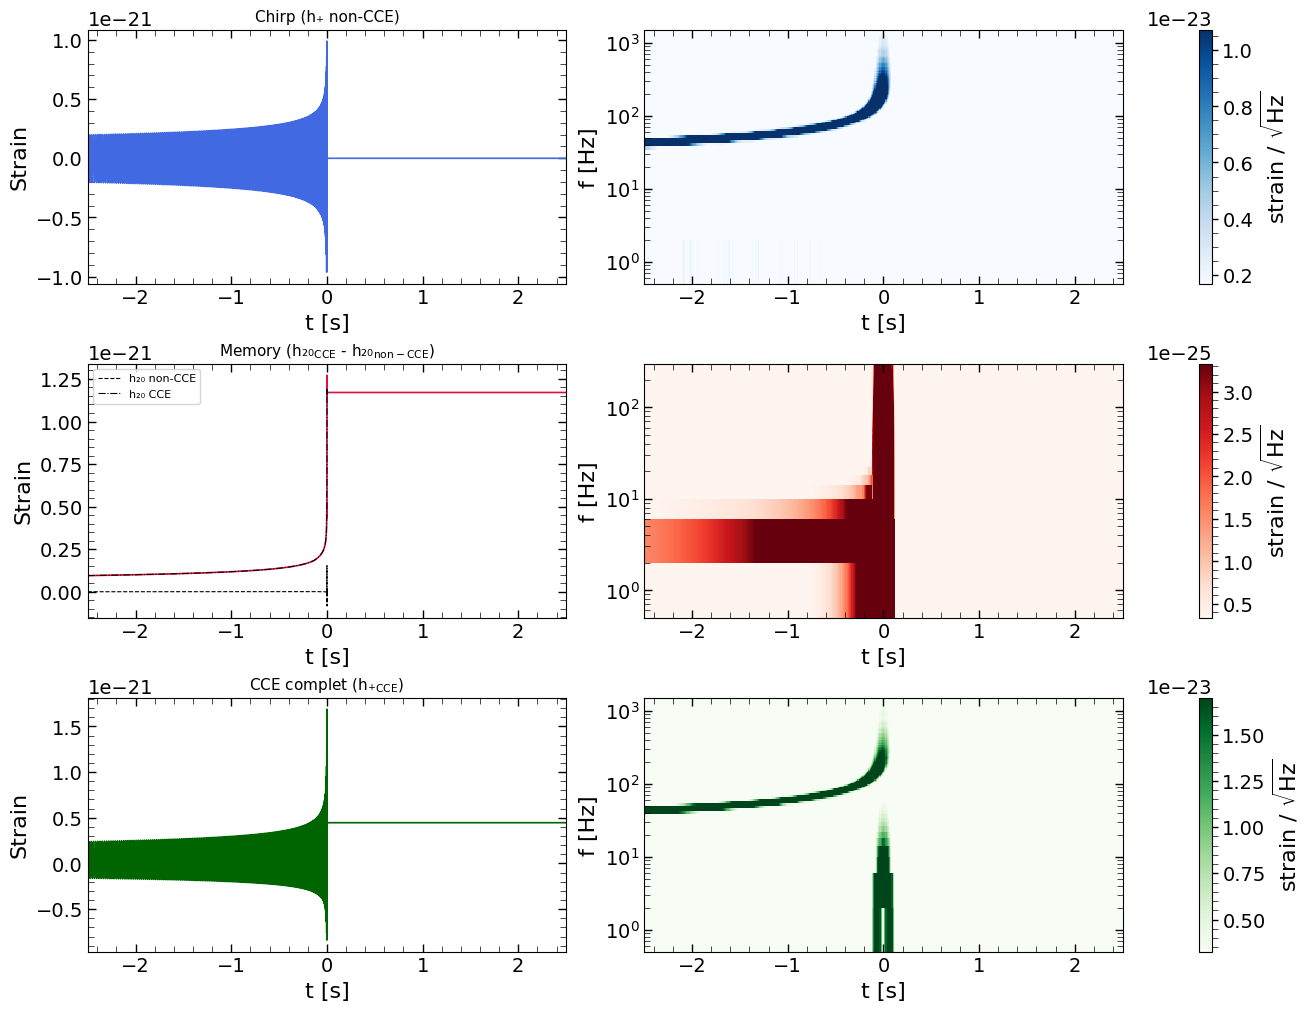

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram as scipy_spectrogram
import gwsurrogate as gws
import utils_signal as usig

# ============================================================
# Parametres
# ============================================================
q = 1.0
chiA = [0.0, 0.0, 0.0]
chiB = [0.0, 0.0, 0.0]

M = 10
dist_mpc = 40.0
dt = 1.0 / 4096.0
fs = 1.0 / dt
f_low = 20.0

inclination = np.pi / 2
phi_ref = 0.0

# ============================================================
# 1) Surrogate NON-CCE
# ============================================================
sur_non_cce = gws.LoadSurrogate("NRHybSur3dq8")

# Modes uniquement (pour memory)
t_non, hlm_non, dyn_non = sur_non_cce(
    q, chiA, chiB,
    M=M,
    dist_mpc=dist_mpc,
    dt=dt,
    f_low=f_low,
    ellMax=4,
    units="mks"
)

# Polarisation h_+ (pour chirp)
t_non_full, h_non_full, dyn_non_full = sur_non_cce(
    q, chiA, chiB,
    M=M,
    dist_mpc=dist_mpc,
    dt=dt,
    f_low=f_low,
    ellMax=4,
    inclination=inclination,
    phi_ref=phi_ref,
    units="mks"
)

# ============================================================
# 2) Surrogate CCE
# ============================================================
sur_cce = gws.LoadSurrogate("NRHybSur3dq8_CCE")

# Modes uniquement (pour memory)
t_cce, hlm_cce, dyn_cce = sur_cce(
    q, chiA, chiB,
    M=M,
    dist_mpc=dist_mpc,
    dt=dt,
    f_low=f_low,
    ellMax=4,
    units="mks"
)

# Polarisation h_+ (pour CCE complet)
t_cce_full, h_cce_full, dyn_cce_full = sur_cce(
    q, chiA, chiB,
    M=M,
    dist_mpc=dist_mpc,
    dt=dt,
    f_low=f_low,
    ellMax=4,
    inclination=inclination,
    phi_ref=phi_ref,
    units="mks"
)

print("Modèles chargés")
print("Modes disponibles (non-CCE):", sorted(hlm_non.keys()))
print("Modes disponibles (CCE):    ", sorted(hlm_cce.keys()))

# ============================================================
# 3) Construction des signaux
# ============================================================
t = np.asarray(t_cce)
t_non_arr = np.asarray(t_non)
t_non_full_arr = np.asarray(t_non_full)
t_cce_full_arr = np.asarray(t_cce_full)

# CHIRP: h_+ du modèle non-CCE (polarisation complète)
h_non_real = np.real(h_non_full)
chirp_raw = np.interp(t, t_non_full_arr, h_non_real)

# MEMORY: différence des modes (2,0) uniquement
h20_non = np.real(hlm_non[(2, 0)])
h20_cce = np.real(hlm_cce[(2, 0)])
h20_non_i = np.interp(t, t_non_arr, h20_non)
memory_raw = h20_cce - h20_non_i

# CCE COMPLET: h_+ du modèle CCE (polarisation complète)
cce_raw = np.interp(t, t_cce_full_arr, np.real(h_cce_full))

print(f"Chirp max: {np.max(np.abs(chirp_raw)):.3e}")
print(f"Memory max: {np.max(np.abs(memory_raw)):.3e}")
print(f"CCE max: {np.max(np.abs(cce_raw)):.3e}")

# ============================================================
# 4) pad_and_taper les signaux
# ============================================================
t_chirp, h_chirp = usig.pad_and_taper(
    chirp_raw, t,
    padding_length=5,
    window_type='tukey',
    alpha=0.
)

t_memory, h_memory = usig.pad_and_taper(
    memory_raw, t,
    padding_length=5,
    window_type='tukey',
    alpha=0.
)

t_cce_padded, h_cce_padded = usig.pad_and_taper(
    cce_raw, t,
    padding_length=5,
    window_type='tukey',
    alpha=0.
)

# ============================================================
# 5) Spectrogrammes
# ============================================================
def make_spec(sig, fs, nperseg=1024, overlap=0.95):
    noverlap = int(overlap * nperseg)
    f, tt, Sxx = scipy_spectrogram(
        sig, fs=fs, nperseg=nperseg, noverlap=noverlap, window="hann"
    )
    return f, tt, np.sqrt(Sxx)

f_ch, t_ch, A_ch = make_spec(h_chirp, fs)
f_me, t_me, A_me = make_spec(h_memory, fs)
f_cc, t_cc, A_cc = make_spec(h_cce_padded, fs)

# Recaler les temps STFT
t_ch += t_chirp[0]
t_me += t_memory[0]
t_cc += t_cce_padded[0]

# ============================================================
# 6) Normalisations adaptées
# ============================================================
vmin_ch, vmax_ch = np.percentile(A_ch[A_ch > 0], [99.5, 99.0])
vmin_me, vmax_me = np.percentile(A_me[A_me > 0], [99.5, 99.0])
vmin_cc, vmax_cc = np.percentile(A_cc[A_cc > 0], [99.5, 99.0])

print(f"Chirp: vmin={vmin_ch:.3e}, vmax={vmax_ch:.3e}")
print(f"Memory: vmin={vmin_me:.3e}, vmax={vmax_me:.3e}")
print(f"CCE: vmin={vmin_cc:.3e}, vmax={vmax_cc:.3e}")

# ============================================================
# 7) Plot final: 3 rows x 2 columns
# ============================================================
signals = [
    (t_chirp, h_chirp, t_ch, f_ch, A_ch, vmin_ch, vmax_ch, "Chirp (h₊ non-CCE)", "royalblue", "Blues"),
    (t_memory, h_memory, t_me, f_me, A_me, vmin_me, vmax_me, r"Memory (h₂₀$_{\mathrm{CCE}}$ - h₂₀$_{\mathrm{non-CCE}}$)", "crimson", "Reds"),
    (t_cce_padded, h_cce_padded, t_cc, f_cc, A_cc, vmin_cc, vmax_cc, r"CCE complet (h₊$_{\mathrm{CCE}}$)", "darkgreen", "Greens"),
]

fig, axs = plt.subplots(3, 2, figsize=(13, 10), constrained_layout=True)

for i, (tt, sig, t_spec, f_spec, A, vmin, vmax, title, color, cmap) in enumerate(signals):
    # Domaine temporel
    axs[i, 0].plot(tt, sig, color=color, lw=1.2)
    axs[i, 0].set_xlim(-2.5, 2.5)
    axs[i, 0].set_title(title, fontsize=11)
    axs[i, 0].set_xlabel("t [s]")
    axs[i, 0].set_ylabel("Strain")
    if i==1:
        # plot mode (2,0) CCE et non-CCE en pointillés

        axs[i, 0].plot(t, np.real(h20_non_i), color="black", lw=0.8, ls="--", label="h₂₀ non-CCE")

        axs[i, 0].plot(t, np.real(h20_cce), color="black", lw=0.8, ls="-.", label="h₂₀ CCE")
        axs[i, 0].legend(loc="upper left", fontsize=8)
    

    # Spectrogramme (echelle linéaire)
    pcm = axs[i, 1].pcolormesh(
        t_spec, f_spec, A,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    axs[i, 1].set_xlim(-2.5, 2.5)
    axs[i, 1].set_yscale("log")
    axs[i, 1].set_xlabel("t [s]")
    axs[i, 1].set_ylabel("f [Hz]")
    
    # Limites de frequence adaptees
    if i == 1:  # Memory: frequences basses
        axs[i, 1].set_ylim(0.5, 300)
    else:  # Chirp et CCE: frequences plus hautes
        axs[i, 1].set_ylim(0.5, 1500)

    cb = fig.colorbar(pcm, ax=axs[i, 1], label=r"strain / $\sqrt{\mathrm{Hz}}$")
    cb.ax.tick_params(which="both", direction="out", length=4)

plt.show()

Loaded NRHybSur3dq8 model


/usr/local/lib64/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib64/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


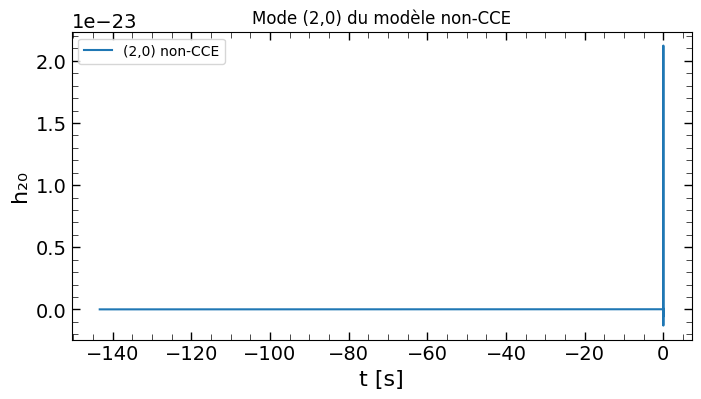

Loaded NRHybSur3dq8_CCE model


/usr/local/lib64/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib64/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


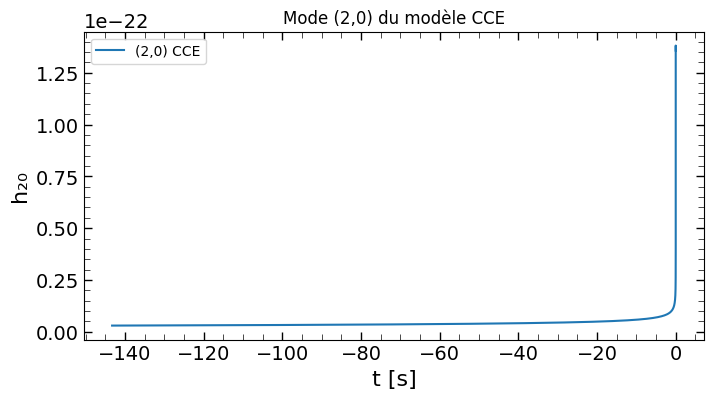

Modèles chargés
Chirp max: 1.603e-22
Memory max: 1.380e-22
CCE max: 4.104e-22
Chirp: vmin=2.039e-24, vmax=5.903e-24
Memory: vmin=2.556e-29, vmax=1.205e-26
CCE: vmin=7.468e-29, vmax=1.001e-25


: 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram as scipy_spectrogram
import gwsurrogate as gws
import utils_signal as usig
import gwmemory

# ============================================================
# Parametres
# ============================================================
q = 1.0
chiA = [0.0, 0.0, 0.0]
chiB = [0.0, 0.0, 0.0]

M = 3.0
dist_mpc = 40.0
dt = 1.0 / 4096.0
fs = 1.0 / dt
f_low = 20.0

inclination = np.pi / 2
phi_ref = 0.0

# ============================================================
# 1) Surrogate NON-CCE
# ============================================================
sur_non_cce = gws.LoadSurrogate("NRHybSur3dq8")

t_non, hlm_non, _ = sur_non_cce(
    q, chiA, chiB,
    M=M, dist_mpc=dist_mpc, dt=dt, f_low=f_low, units="mks", mode_list=[(2,0)],
    inclination=inclination, phi_ref=phi_ref
)
plt.figure(figsize=(8,4))
plt.plot(t_non, hlm_non, label="(2,0) non-CCE")
plt.xlabel("t [s]")
plt.ylabel("h₂₀")
plt.title("Mode (2,0) du modèle non-CCE")
plt.legend()
plt.show()

t_non_full, h_non_full, _ = sur_non_cce(
    q, chiA, chiB,
    M=M, dist_mpc=dist_mpc, dt=dt, f_low=f_low, ellMax=4,
    inclination=inclination, phi_ref=phi_ref, units="mks"
)

# ============================================================
# 2) Surrogate CCE
# ============================================================
sur_cce = gws.LoadSurrogate("NRHybSur3dq8_CCE")

t_cce, hlm_cce, _ = sur_cce(
    q, chiA, chiB,
    M=M, dist_mpc=dist_mpc, dt=dt, f_low=f_low, units="mks", mode_list=[(2,0)],
    inclination=inclination, phi_ref=phi_ref
    
)
plt.figure(figsize=(8,4))
plt.plot(t_cce, hlm_cce, label="(2,0) CCE")
plt.xlabel("t [s]")
plt.ylabel("h₂₀")
plt.title("Mode (2,0) du modèle CCE")
plt.legend()
plt.show()

t_cce_full, h_cce_full, _ = sur_cce(
    q, chiA, chiB,
    M=M, dist_mpc=dist_mpc, dt=dt, f_low=f_low, ellMax=4,
    inclination=inclination, phi_ref=phi_ref, units="mks"
)

print("Modèles chargés")

# ============================================================
# 3) Construction des signaux
# ============================================================
t = np.asarray(t_cce)
t_non_arr = np.asarray(t_non)
t_non_full_arr = np.asarray(t_non_full)
t_cce_full_arr = np.asarray(t_cce_full)

# CHIRP: h_+ du modèle non-CCE
chirp_raw = np.interp(t, t_non_full_arr, np.real(h_non_full))

# MEMORY: différence des modes (2,0) ← MODE (2,0), PAS POLARISATIONS COMPLÈTES
h20_non = np.real(hlm_non)
h20_cce = np.real(hlm_cce)
h20_non_i = np.interp(t, t_non_arr, h20_non)
memory_raw = h20_cce - h20_non_i

# CCE COMPLET: h_+ du modèle CCE
cce_raw = np.interp(t, t_cce_full_arr, np.real(h_cce_full))

print(f"Chirp max: {np.max(np.abs(chirp_raw)):.3e}")
print(f"Memory max: {np.max(np.abs(memory_raw)):.3e}")
print(f"CCE max: {np.max(np.abs(cce_raw)):.3e}")



# ============================================================
# 5) pad_and_taper les signaux
# ============================================================
t_chirp, h_chirp = usig.pad_and_taper(
    chirp_raw, t, padding_length=50, window_type='tukey', alpha=0.
)

t_memory, h_memory = usig.pad_and_taper(
    memory_raw, t, padding_length=50, window_type='tukey', alpha=0.
)

t_cce_padded, h_cce_padded = usig.pad_and_taper(
    cce_raw, t, padding_length=50, window_type='tukey', alpha=0.
)



# ============================================================
# 6) Spectrogrammes
# ============================================================
def make_spec(sig, fs, nperseg=1024, overlap=0.95):
    noverlap = int(overlap * nperseg)
    f, tt, Sxx = scipy_spectrogram(
        sig, fs=fs, nperseg=nperseg, noverlap=noverlap, window="hann"
    )
    return f, tt, np.sqrt(Sxx)

f_ch, t_ch, A_ch = make_spec(h_chirp, fs)
f_me, t_me, A_me = make_spec(h_memory, fs)
f_cc, t_cc, A_cc = make_spec(h_cce_padded, fs)

# Recaler les temps STFT
t_ch += t_chirp[0]
t_me += t_memory[0]
t_cc += t_cce_padded[0]

# ============================================================
# 7) Normalisations
# ============================================================
vmin_ch, vmax_ch = np.percentile(A_ch[A_ch > 0], [99.5, 99.9])
vmin_me, vmax_me = np.percentile(A_me[A_me > 0], [99.5, 99.9])
vmin_cc, vmax_cc = np.percentile(A_cc[A_cc > 0], [95, 99.0])

print(f"Chirp: vmin={vmin_ch:.3e}, vmax={vmax_ch:.3e}")
print(f"Memory: vmin={vmin_me:.3e}, vmax={vmax_me:.3e}")
print(f"CCE: vmin={vmin_cc:.3e}, vmax={vmax_cc:.3e}")

# ============================================================
# 8) Plot
# ============================================================
signals = [
    (t_chirp, h_chirp, t_ch, f_ch, A_ch, vmin_ch, vmax_ch, r"Chirp (h₊$_{\mathrm{non-CCE}}$)", "royalblue", "Blues"),
    (t_memory, h_memory, t_me, f_me, A_me, vmin_me, vmax_me, r"Memory (h$_{(2,0),\mathrm{CCE}}^+$ - h$_{(2,0),\mathrm{non-CCE}}^+$)", "crimson", "Reds"),
    (t_cce_padded, h_cce_padded, t_cc, f_cc, A_cc, vmin_cc, vmax_cc, r"CCE complet (h₊$_{\mathrm{CCE}}$)", "darkgreen", "Greens"),
]

fig, axs = plt.subplots(3, 2, figsize=(13, 10), constrained_layout=True)

for i, (tt, sig, t_spec, f_spec, A, vmin, vmax, title, color, cmap) in enumerate(signals):
    # Domaine temporel
    axs[i, 0].plot(tt, sig, color=color, lw=1.2)

    
    axs[i, 0].set_xlim(-2.5, 2.5)
    axs[i, 0].set_title(title, fontsize=11)
    axs[i, 0].set_xlabel("t [s]")
    axs[i, 0].set_ylabel("Strain")
    axs[i, 0].grid(False)

    # Spectrogramme
    pcm = axs[i, 1].pcolormesh(
        t_spec, f_spec, A, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax
    )
    axs[i, 1].set_xlim(-2.5, 2.5)
    axs[i, 1].set_yscale("log")
    axs[i, 1].set_xlabel("t [s]")
    axs[i, 1].set_ylabel("f [Hz]")
    
    if i == 1:
        axs[i, 1].set_ylim(0.5, 300)
    else:
        axs[i, 1].set_ylim(0.5, 1500)

    cb = fig.colorbar(pcm, ax=axs[i, 1], label=r"strain / $\sqrt{\mathrm{Hz}}$")
    cb.ax.tick_params(which="both", direction="out", length=4)

plt.show()

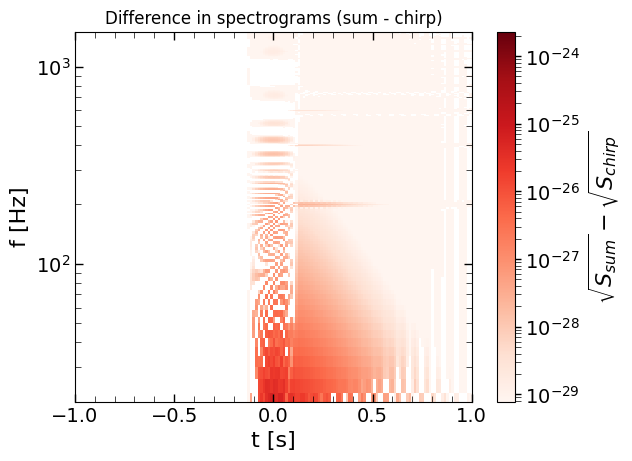

In [8]:
amp_diff = amp_sum - amp_chirp
plt.pcolormesh(t_spec_s, f_spec_s, amp_diff, shading='auto', cmap='Reds', norm=LogNorm(vmin=np.percentile(amp_diff[amp_diff > 0], 99), vmax=np.max(amp_diff)))
cb = plt.colorbar(label=r'$\sqrt{S_{sum}} - \sqrt{S_{chirp}}$')
cb.ax.tick_params(which='both', direction='out', length=4)

plt.ylim(20, 1500)
plt.xlim(-1, 1)
plt.xlabel('t [s]')
plt.ylabel('f [Hz]')
plt.yscale('log')

plt.title('Difference in spectrograms (sum - chirp)')
plt.grid(False)
plt.show()